# Find edge projectors initial test
Created 10/08/2026

Objectives:
* Try and find edge projectors for these states. Can we find the resulting defect operators too?

# Package imports

In [1]:
import sys

In [2]:
sys.path.append("../../")

In [3]:
from itertools import chain, combinations
from collections import defaultdict
import re

In [4]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

In [5]:
import numpy as np
import jax.numpy as jnp

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib

In [6]:
import quimb as qu
import quimb.tensor as qtn
from quimb.tensor.optimize import TNOptimizer

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [7]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d

In [166]:
from itertools import cycle

# Load data

In [8]:
L=20
basis = spin_basis_1d(L)

In [10]:
DATA_DIR = r"../../data/quspin_transverse_cluster_20_site"

In [12]:
energies = [
    np.load(rf'{DATA_DIR}/{i}.npz')['energy']
    for i in range(0, 101, 5)
]

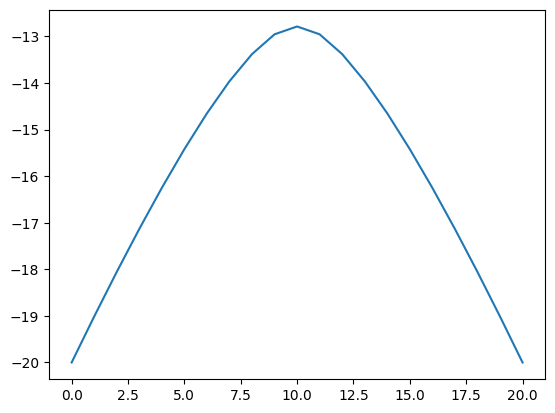

In [13]:
plt.plot(energies)

In [15]:
energies[0], energies[-1]

(array([-20.]), array([-20.]))

In [16]:
groundstates = [
    np.load(rf'{DATA_DIR}/{i}.npz')['psi']
    for i in range(0, 101, 5)
]

In [17]:
parameters = np.linspace(0, 1, 21)

In [18]:
parameters

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [21]:
inds = [f'k{i}' for i in range(L)]

qt_groundstates = [
    qtn.Tensor(
        psi[::-1].reshape((2,)*L),
        inds=inds
    )
    for psi in groundstates
]

# Definitions

In [162]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])

In [163]:
qu_I = qtn.Tensor(np_I, inds=['k', 'b'])
qu_X = qtn.Tensor(np_X, inds=['k', 'b'])

In [164]:
symmetry_actions = [
    [qu_I, qu_I],
    [qu_I, qu_X],
    [qu_X, qu_I],
    [qu_X, qu_X]
]

In [165]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

In [154]:
def generate_edm(cut_psi, sites, symmetry_pair, num_defect_sites):
    assert 2*num_defect_sites < len(sites)

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_symmetry_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    left_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in left_defect_sites
    ]

    inner_gates = [
        symmetry_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in internal_sites
    ]
    
    right_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in right_defect_sites
    ]

    # And re-index psi also.

    q_top = quimb_psi.copy(deep=True)
    for i, s in symmetry_site_pairs:
        q_top.gate(
            s,
            where=i,
            contract=False,
            inplace=True
        )

    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        leftmost_symmetry_site
    ))

    right_boundary_sites = list(range(
        leftmost_symmetry_site+num_symmetry_sites,
        leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites
    ))
    
    indices_to_map = list(chain(left_boundary_sites, right_boundary_sites))

    index_mapping = {f'k{i}': f'b{i}' for i in indices_to_map}

    q_bottom = (
        quimb_psi
        .copy()
        .reindex(index_mapping, inplace=True)
        .conj()
    )

    sites_to_contract = {
        'left': list(range(leftmost_symmetry_site-num_boundary_sites)),
        'middle': list(range(leftmost_symmetry_site, leftmost_symmetry_site+num_symmetry_sites)),
        'right': list(range(leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites, quimb_psi.L))
    }

    tags_to_contract = {
        k: [f'I{i}' for i in v]
        for k, v in sites_to_contract.items()
    }

    tn = (q_top & q_bottom)

    """
    tnc = (
        tn
        .contract(tags_to_contract['left'])
        .contract(tags_to_contract['middle'])
        .contract(tags_to_contract['right'])
    )
    """

    tnc = tn.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_boundary_sites)),
        ('b_left', (f'b{i}' for i in left_boundary_sites)),
        ('k_right', (f'k{i}' for i in right_boundary_sites)),
        ('b_right', (f'b{i}' for i in right_boundary_sites))
    ]

    tnc.fuse(fuse_maps, inplace=True)

    return tnc

## Optimisation functions

In [155]:
def solve_for_boundary_operators(rdm, num_iters=20):
    scores = list()

    u_left = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_rdm = (rdm & u_left).contract()
        data = right_rdm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])
        
        left_rdm = (rdm & u_right).contract()
        data = left_rdm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

# Test

In [101]:
left_rho_sites = list(range(8, 10))
right_rho_sites = list(range(10, 12))

rho_sites = left_rho_sites + right_rho_sites

In [102]:
psi = qt_groundstates[-1]
rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

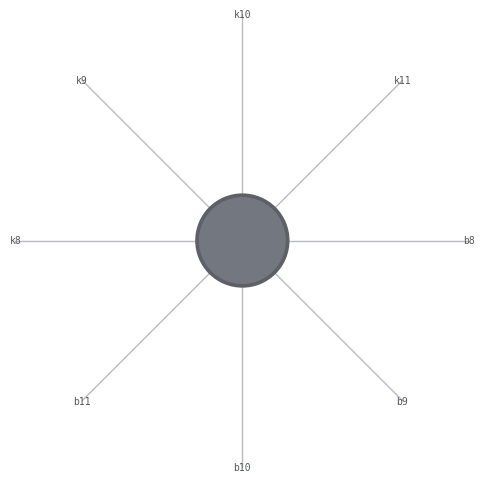

In [69]:
rho.draw()

In [70]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [71]:
left_state = qtn.Tensor(
    data=random_uniform_complex((2,)*len(left_rho_sites)),
    inds=[f'k{i}' for i in left_rho_sites]
)

right_state = qtn.Tensor(
    data=random_uniform_complex((2,)*len(right_rho_sites)),
    inds=[f'k{i}' for i in right_rho_sites]
)

In [72]:
(
    rho
    & left_state
    & right_state
    & left_state.conj().reindex({f'k{i}': f'b{i}' for i in left_rho_sites})
    & right_state.conj().reindex({f'k{i}': f'b{i}' for i in right_rho_sites})
).contract()

(0.9526661287857219+1.1102230246251565e-16j)

In [95]:
help(rho.unfuse)

Help on method unfuse in module quimb.tensor.tensor_core:

unfuse(unfuse_map, shape_map, inplace=False) method of quimb.tensor.tensor_core.Tensor instance
    Reshape single indices into groups of multiple indices
    
    Parameters
    ----------
    unfuse_map : dict_like or sequence of tuples.
        Mapping like: ``{existing_ind: sequence of new inds, ...}`` or an
        ordered mapping like ``[(old_ind_1, new_inds_1), ...]`` in which
        case the output tensor's new inds will be ordered. In both cases
        the new indices are created at the old index's position of the
        tensor's shape
    shape_map : dict_like or sequence of tuples
        Mapping like: ``{old_ind: new_ind_sizes, ...}`` or an
        ordered mapping like ``[(old_ind_1, new_ind_sizes_1), ...]``.
    
    Returns
    -------
    Tensor
        The transposed, reshaped and re-labeled tensor



In [124]:
def maximize_projector_states(rho, left_rho_sites, right_rho_sites,
                              num_iters=20):
    scores = list()

    left_k_inds = [f'k{i}' for i in left_rho_sites]
    left_b_inds = [f'b{i}' for i in left_rho_sites]
    right_k_inds = [f'k{i}' for i in right_rho_sites]
    right_b_inds = [f'b{i}' for i in right_rho_sites]

    fused_rho = rho.fuse({
        'kl': left_k_inds,
        'kr': right_k_inds,
        'bl': left_b_inds,
        'br': right_b_inds
    })

    left_state = qtn.Tensor(
        data=random_uniform_complex((2**len(left_rho_sites),)),
        inds=['kl',]
    )
    
    right_state = qtn.Tensor(
        data=random_uniform_complex((2**len(right_rho_sites),)),
        inds=['kr',]
    )

    for i in range(num_iters):
        right_matrix = (
            fused_rho
            & left_state.conj()
            & left_state.reindex({'kl': 'bl'})
        ).contract()
        data = (
            right_matrix
            .transpose('kr', 'br')
            .data
        )

        eigvals, eigvecs = np.linalg.eig(data)

        index = np.argmax(np.abs(eigvals))
        score = np.abs(eigvals[index])
        state_data = eigvecs[:, index]

        right_state = qtn.Tensor(
            data=state_data,
            inds=['kr',]
        )
        scores.append(score)

        left_matrix = (
            fused_rho
            & right_state.conj()
            & right_state.reindex({'kr': 'br'})
        ).contract()
        data = (
            left_matrix
            .transpose('kl', 'bl')
            .data
        )

        eigvals, eigvecs = np.linalg.eig(data)

        index = np.argmax(np.abs(eigvals))
        score = np.abs(eigvals[index])
        state_data = eigvecs[:, index]

        left_state = qtn.Tensor(
            data=state_data,
            inds=['kl',]
        )
        scores.append(score)

    left_state.unfuse(
        {'kl': left_k_inds},
        shape_map={'kl': (2,)*len(left_k_inds)},
        inplace=True
    )
    right_state.unfuse(
        {'kr': right_k_inds},
        shape_map={'kr': (2,)*len(right_k_inds)},
        inplace=True
    )

    return scores, (left_state, right_state)

In [104]:
test_out = maximize_projector_states(
    rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

In [105]:
test_scores = test_out[0]

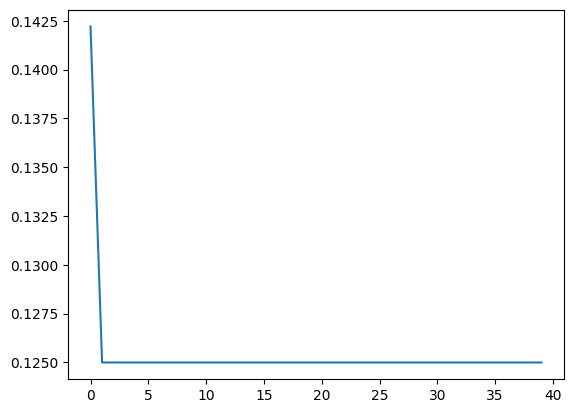

In [106]:
plt.plot(test_scores)

In [107]:
test_scores

[0.14220827544583292,
 0.12500000000000003,
 0.12500000000000003,
 0.12499999999999997,
 0.12500000000000006,
 0.12500000000000003,
 0.12499999999999996,
 0.125,
 0.125,
 0.12500000000000006,
 0.1250000000000001,
 0.12500000000000003,
 0.12500000000000006,
 0.12500000000000006,
 0.1250000000000001,
 0.12500000000000006,
 0.125,
 0.12500000000000003,
 0.12500000000000006,
 0.12499999999999997,
 0.125,
 0.12500000000000006,
 0.12500000000000008,
 0.12499999999999999,
 0.12499999999999996,
 0.12500000000000006,
 0.12499999999999996,
 0.12500000000000006,
 0.125,
 0.12499999999999997,
 0.1250000000000001,
 0.12500000000000006,
 0.12500000000000006,
 0.12499999999999999,
 0.1250000000000001,
 0.125,
 0.12500000000000006,
 0.12500000000000006,
 0.12500000000000014,
 0.125]

In [118]:
left_rho_sites = list(range(4, 6))
right_rho_sites = list(range(6, 8))

rho_sites = left_rho_sites + right_rho_sites

In [119]:
left_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

In [123]:
help(left_rho.unfuse)

Help on method unfuse in module quimb.tensor.tensor_core:

unfuse(unfuse_map, shape_map, inplace=False) method of quimb.tensor.tensor_core.Tensor instance
    Reshape single indices into groups of multiple indices
    
    Parameters
    ----------
    unfuse_map : dict_like or sequence of tuples.
        Mapping like: ``{existing_ind: sequence of new inds, ...}`` or an
        ordered mapping like ``[(old_ind_1, new_inds_1), ...]`` in which
        case the output tensor's new inds will be ordered. In both cases
        the new indices are created at the old index's position of the
        tensor's shape
    shape_map : dict_like or sequence of tuples
        Mapping like: ``{old_ind: new_ind_sizes, ...}`` or an
        ordered mapping like ``[(old_ind_1, new_ind_sizes_1), ...]``.
    
    Returns
    -------
    Tensor
        The transposed, reshaped and re-labeled tensor



In [125]:
left_test_out = maximize_projector_states(
    left_rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

In [126]:
left_rho_sites = list(range(12, 14))
right_rho_sites = list(range(14, 16))

rho_sites = left_rho_sites + right_rho_sites

In [127]:
right_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

In [128]:
right_test_out = maximize_projector_states(
    right_rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

In [129]:
right_test_out[0]

[0.14009789390283373,
 0.12500000000000017,
 0.12500000000000003,
 0.12500000000000003,
 0.125,
 0.12500000000000006,
 0.12500000000000017,
 0.12500000000000006,
 0.12500000000000006,
 0.12500000000000008,
 0.12500000000000003,
 0.12500000000000006,
 0.12500000000000008,
 0.12499999999999999,
 0.12499999999999993,
 0.12500000000000008,
 0.1250000000000001,
 0.125,
 0.12500000000000003,
 0.1250000000000001,
 0.12500000000000006,
 0.12500000000000003,
 0.12499999999999994,
 0.125,
 0.12500000000000006,
 0.12500000000000006,
 0.12500000000000006,
 0.12500000000000003,
 0.12500000000000003,
 0.12500000000000006,
 0.125,
 0.1250000000000001,
 0.12500000000000006,
 0.125,
 0.1250000000000001,
 0.12500000000000003,
 0.12499999999999997,
 0.12499999999999997,
 0.125,
 0.1250000000000001]

In [130]:
left_test_out[0]

[0.2503188888225436,
 0.125,
 0.12500000000000006,
 0.125,
 0.12499999999999994,
 0.125,
 0.12499999999999997,
 0.12499999999999997,
 0.12500000000000003,
 0.12499999999999997,
 0.12499999999999997,
 0.12499999999999999,
 0.125,
 0.12500000000000008,
 0.12500000000000003,
 0.125,
 0.125,
 0.12500000000000006,
 0.12500000000000008,
 0.12499999999999999,
 0.12500000000000008,
 0.12500000000000008,
 0.125,
 0.125,
 0.125,
 0.1250000000000001,
 0.125,
 0.12499999999999997,
 0.125,
 0.12500000000000003,
 0.12499999999999999,
 0.12499999999999999,
 0.125,
 0.12499999999999996,
 0.12499999999999999,
 0.12500000000000006,
 0.125,
 0.125,
 0.125,
 0.12500000000000003]

In [131]:
left_test_out[1]

(Tensor(shape=(2, 2), inds=('k4', 'k5'), tags=oset([])),
 Tensor(shape=(2, 2), inds=('k6', 'k7'), tags=oset([])))

In [134]:
left_proj_state = left_test_out[1][1]
right_proj_state = right_test_out[1][0]

In [133]:
psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k0', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15', 'k16', 'k17', 'k18', 'k19'), tags=oset([]))

In [135]:
left_proj_state

Tensor(shape=(2, 2), inds=('k6', 'k7'), tags=oset([]))

In [136]:
right_proj_state

Tensor(shape=(2, 2), inds=('k12', 'k13'), tags=oset([]))

In [137]:
proj_psi = (
    psi.reindex({'k6': 'b6', 'k7': 'b7', 'k12': 'b12', 'k13': 'b13'})
    & left_proj_state.conj().reindex({'k6': 'b6', 'k7': 'b7'})
    & left_proj_state
    & right_proj_state.conj().reindex({'k12': 'b12', 'k13': 'b13'})
    & right_proj_state
)

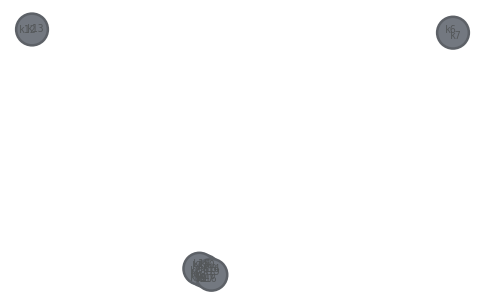

In [139]:
proj_psi.draw()

In [140]:
proj_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=20)

In [142]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [144]:
proj_psi = np.power(norm, -0.5)*proj_psi

In [145]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [146]:
norm

(0.9999999999999993+0j)

Check Schmidt decomposition

In [149]:
proj_psi

TensorNetwork(tensors=1, indices=20)

In [150]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    proj_psi.tensors[0],
    left_inds=[f'k{i}' for i in range(6, 14)],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vLV'
)

In [153]:
schmidt_decomp.tensors[1].data

array([1.])

Nice, clean cut.

In [156]:
schmidt_decomp

TensorNetwork(tensors=3, indices=21)

In [157]:
cut_psi = schmidt_decomp.tensors[0]

In [160]:
cut_psi = cut_psi.isel({'vLV':0})

In [161]:
cut_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13'), tags=oset([]))

In [ ]:
num_boundary_sites=2
leftmost_symmetry_site=4
num_symmetry_sites=6

In [ ]:
for k2, bs in enumerate(symmetry_actions[1:], start=1):
    symmetry_site_pairs = (
        [(i, bs[0]) for i in range(left_most_symmetry_site, left_most_symmetry_site+num_symmetry_sites, 2)]
        + [(i, bs[1]) for i in range(left_most_symmetry_site+1, left_most_symmetry_site+num_symmetry_sites+1, 2)]
    )

    rdm = generate_problem_rdm(
        psi,
        symmetry_site_pairs,
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites
    )

    (u_left, u_right), scores = solve_for_boundary_operators(
        rdm,
        num_iters=num_iterations
    )

    file_name = rf'svd_solutions_2_site/{k1}_{k2}.pickle'

    with open(file_name, 'wb') as file:
        pickle.dump(((u_left, u_right), scores), file)

# Definitions

In [28]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])

In [29]:
symmetry_actions = [
    [np_I, np_I],
    [np_I, np_X],
    [np_X, np_I],
    [np_X, np_X]
]

In [30]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

In [31]:
def generate_problem_rdm(quimb_psi, symmetry_site_pairs, leftmost_symmetry_site,
                         num_symmetry_sites, num_boundary_sites):
    q_top = quimb_psi.copy(deep=True)
    for i, s in symmetry_site_pairs:
        q_top.gate(
            s,
            where=i,
            contract=False,
            inplace=True
        )

    
    indices_to_map = list(chain(
        range(leftmost_symmetry_site-num_boundary_sites, leftmost_symmetry_site),
        range(leftmost_symmetry_site+num_symmetry_sites, leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites)
    ))

    index_mapping = {f'k{i}': f'b{i}' for i in indices_to_map}

    q_bottom = (
        quimb_psi
        .copy()
        .reindex(index_mapping, inplace=True)
        .conj()
    )

    sites_to_contract = {
        'left': list(range(leftmost_symmetry_site-num_boundary_sites)),
        'middle': list(range(leftmost_symmetry_site, leftmost_symmetry_site+num_symmetry_sites)),
        'right': list(range(leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites, quimb_psi.L))
    }

    tags_to_contract = {
        k: [f'I{i}' for i in v]
        for k, v in sites_to_contract.items()
    }

    tn = (q_top & q_bottom)

    """
    tnc = (
        tn
        .contract(tags_to_contract['left'])
        .contract(tags_to_contract['middle'])
        .contract(tags_to_contract['right'])
    )
    """

    tnc = tn.contract()

    return tnc

In [32]:
def generate_rdm(quimb_psi, left_site_index, right_site_index):
    indices_to_map = list(range(left_site_index, right_site_index + 1))

    index_mapping = {f'k{i}': f'b{i}' for i in indices_to_map}

    q_bottom = (
        quimb_psi
        .copy()
        .reindex(index_mapping, inplace=True)
        .conj()
    )

    tn = (quimb_psi & q_bottom)
    tnc = tn.contract()

    return tnc

In [33]:
def generate_boundary_rdms(quimb_psi, leftmost_symmetry_site,
    num_symmetry_sites, num_boundary_sites):

    left_rdm = generate_rdm(
        quimb_psi,
        leftmost_symmetry_site-num_boundary_sites,
        leftmost_symmetry_site-1
    )

    right_rdm = generate_rdm(
        quimb_psi,
        leftmost_symmetry_site+num_symmetry_sites,
        leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites-1
    )

    return left_rdm, right_rdm

## Optimisation functions

In [34]:
def split_mpo_pair(mpo_pair):
    ml = qtn.TensorNetwork(
        list(map(mpo_pair.tensor_map.__getitem__, mpo_pair.tag_map['left_mpo']))
    )

    mr = qtn.TensorNetwork(
        list(map(mpo_pair.tensor_map.__getitem__, mpo_pair.tag_map['right_mpo']))
    )

    return (ml, mr)

In [35]:
def overlap_loss_function(ml, mr, rdm_tn, epsilon=0):
    c = (rdm_tn & ml & mr) ^ ...

    c_abs_squared = (
        c
        *jnp.conjugate(c)
    )
    #c_abs_squared = c_abs_squared.astype('float32')
    c_abs = (jnp.sqrt(c_abs_squared+epsilon))

    target = jnp.sqrt(1+epsilon)
    loss = (c_abs - target)**2

    return loss

In [36]:
def overlap_loss_function_mpo_pair(mpo_pair, rdm_tn):
    ml, mr = split_mpo_pair(mpo_pair)

    return overlap_loss_function(ml, mr, rdm_tn)

In [37]:
regex_s = r"^I\d+$"
regex_p = re.compile(regex_s)

In [38]:
def relabel_mpo(mpo, k_label, b_label):
    site_locs = [
        int(k[1:]) for k in mpo.tag_map
        if bool(re.search(regex_p, k))
    ]

    k_in_indices = [f'k{i}' for i in site_locs]
    j_in_indices = [f'b{i}' for i in site_locs]

    k_out_indices = [f'{k_label}{i}' for i in site_locs]
    j_out_indices = [f'{b_label}{i}' for i in site_locs]

    mapping = dict(
        chain(
            zip(k_in_indices, k_out_indices),
            zip(j_in_indices, j_out_indices)
        )
    )

    mpo.reindex(mapping, inplace=True)

In [39]:
def unitarity_tn(tn, total_physical_dim):
    ms = [tn.copy(), tn.copy(), tn.copy()]

    relabel_mpo(ms[0], 'k', 'l')
    relabel_mpo(ms[1], 'm', 'l')
    relabel_mpo(ms[2], 'm', 'b')

    ms[0] = ms[0].conj()
    ms[2] = ms[2].conj()

    n2tn = (tn & tn.conj())
    n2 = n2tn.contract(n2tn.tag_map)
    n4tn = (tn & ms[0] & ms[1] & ms[2])
    n4 = n4tn.contract(n4tn.tag_map)

    out = jnp.real(n4 - 2*n2 + total_physical_dim)

    return out

In [40]:
def overall_loss_function(mpo_pair, rdm_tn, total_physical_dimension,
    unitary_cost_coefficient=1, overlap_cost_coefficient=1, losses=None):
    ml, mr = split_mpo_pair(mpo_pair)

    o_loss = overlap_loss_function(ml, mr, rdm_tn)
    ul_loss = unitarity_tn(ml, total_physical_dimension)
    ur_loss = unitarity_tn(mr, total_physical_dimension)

    out = (
        unitary_cost_coefficient*(ul_loss+ur_loss)
        + overlap_cost_coefficient*o_loss
    )

    out = jnp.real(out)

    if losses is not None:
        losses.append((o_loss, ul_loss, ur_loss))
    return out

## SPT extraction functions

In [41]:
symmetry_combination_labels = list(combinations(symmetry_labels, 2))

In [42]:
symmetry_combination_labels

[('II', 'IX'),
 ('II', 'XI'),
 ('II', 'XX'),
 ('IX', 'XI'),
 ('IX', 'XX'),
 ('XI', 'XX')]

In [43]:
e, a, b, c = symmetry_labels

In [44]:
group_products = [
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (c, b, a),
    (b, c, a)
]

In [45]:
test_psi = psi_dict[0]

In [46]:
test_psi

<npc.Array shape=(16384,) labels=['ps']>

In [47]:
quimb_psi = qtn.Dense1D(
    test_psi.to_ndarray(),
    phys_dim=2
)

In [48]:
quimb_psi

Dense1D(tensors=1, indices=14, L=14, max_bond=None)

In [49]:
test_mpo = split_mpo_pair(best_boundary_operators[(0,1)][1])[1]

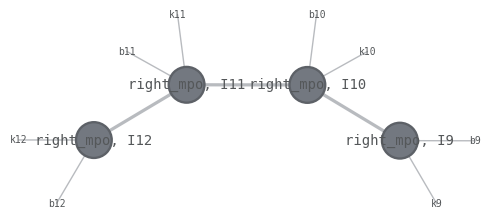

In [50]:
test_mpo.draw()

In [51]:
def get_proj_rep_phase(rho, u_g, u_h, u_gh):
    us = [u_g.copy(), u_h.copy(), u_gh.copy()]

    relabel_mpo(us[0], 'l', 'k')
    relabel_mpo(us[1], 'm', 'l')
    relabel_mpo(us[2], 'b', 'm')

    us[2] = us[2].conj()

    tn = rho & us[0] & us[1] & us[2]
    exp = tn.contract(tn.tag_map)

    out = exp/np.abs(exp)

    return out

In [52]:
def tensor_network_to_mpo(tn):
    sites = [
        int(s[1:]) for s in tn.tag_map
        if s[0]=='I'
    ]
    
    rho = qtn.MatrixProductOperator(
        [t.data for t in tn.tensors],
        sites=sites
    )

    return rho

In [53]:
def get_proj_rep_phases(rho, unitaries):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()
    for a, b, c in group_products:
        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c]
        )

        out_phases.append(phase)

    return out_phases

# Extract phases

In [54]:
b_params = np.round(np.linspace(0, 2, 21), 3)

In [55]:
num_boundary_sites=4
leftmost_symmetry_site=5
num_symmetry_sites=4

In [56]:
proj_rep_phases = list()

for t in b_params:
    tenpy_psi = psi_dict[t]

    quimb_psi = qtn.Dense1D(
        tenpy_psi.to_ndarray(),
        phys_dim=2
    )

    left_rdm, right_rdm = generate_boundary_rdms(
        quimb_psi,
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites
    )

    unitaries = [best_boundary_operators[(t, i)][1] for i in [1,2,3]]

    unitary_pairs = [split_mpo_pair(p) for p in unitaries]
    mpo_pairs = [(tensor_network_to_mpo(x), tensor_network_to_mpo(y)) for x,y in unitary_pairs]
    left_unitaries, right_unitaries = zip(*mpo_pairs)

    left_phases = get_proj_rep_phases(left_rdm, left_unitaries)
    right_phases = get_proj_rep_phases(right_rdm, right_unitaries)

    proj_rep_phases.append([left_phases, right_phases])

In [57]:
proj_rep_phases = np.array(proj_rep_phases)

In [58]:
proj_rep_phases.shape

(21, 2, 6)

In [59]:
b_params

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ])

In [60]:
len(b_params)

21

In [61]:
np.round(
    proj_rep_phases[..., ::2]/proj_rep_phases[..., 1::2],
    2
)

array([[[-1.-0.j  , -1.+0.j  , -1.-0.j  ],
        [-1.+0.j  , -1.-0.j  , -1.+0.j  ]],

       [[-1.-0.j  , -1.-0.j  , -1.-0.j  ],
        [-1.-0.j  , -1.-0.j  , -1.-0.j  ]],

       [[-1.+0.j  , -1.+0.j  , -1.+0.j  ],
        [-1.+0.j  , -1.-0.j  , -1.-0.j  ]],

       [[-1.-0.j  , -1.-0.j  , -1.-0.j  ],
        [-1.+0.j  , -1.-0.j  , -1.+0.j  ]],

       [[-1.-0.02j, -1.+0.j  , -1.-0.02j],
        [-1.-0.01j, -1.-0.j  , -1.-0.01j]],

       [[-1.-0.j  , -1.-0.j  , -1.+0.j  ],
        [-1.-0.j  , -1.-0.j  , -1.-0.j  ]],

       [[-1.+0.j  , -1.-0.01j, -1.+0.j  ],
        [-1.+0.j  , -1.+0.j  , -1.-0.01j]],

       [[-1.-0.j  , -1.-0.j  , -1.-0.j  ],
        [-1.+0.j  , -1.+0.j  , -1.+0.j  ]],

       [[ 1.+0.j  ,  1.+0.j  ,  1.+0.j  ],
        [ 1.-0.j  ,  1.+0.j  ,  1.+0.j  ]],

       [[ 1.-0.01j,  1.+0.01j,  1.-0.01j],
        [ 1.+0.01j,  1.+0.01j,  1.-0.j  ]],

       [[ 1.-0.j  ,  1.-0.01j,  1.+0.j  ],
        [ 1.-0.j  ,  1.-0.j  ,  1.-0.01j]],

       [[ 1.+0.j  ,  1.+0.04j,  

In [62]:
gauge_invariant_proj_rep_phase = proj_rep_phases[..., ::2]/proj_rep_phases[..., 1::2]

In [63]:
np.round(gauge_invariant_proj_rep_phase[:8], 2)

array([[[-1.-0.j  , -1.+0.j  , -1.-0.j  ],
        [-1.+0.j  , -1.-0.j  , -1.+0.j  ]],

       [[-1.-0.j  , -1.-0.j  , -1.-0.j  ],
        [-1.-0.j  , -1.-0.j  , -1.-0.j  ]],

       [[-1.+0.j  , -1.+0.j  , -1.+0.j  ],
        [-1.+0.j  , -1.-0.j  , -1.-0.j  ]],

       [[-1.-0.j  , -1.-0.j  , -1.-0.j  ],
        [-1.+0.j  , -1.-0.j  , -1.+0.j  ]],

       [[-1.-0.02j, -1.+0.j  , -1.-0.02j],
        [-1.-0.01j, -1.-0.j  , -1.-0.01j]],

       [[-1.-0.j  , -1.-0.j  , -1.+0.j  ],
        [-1.-0.j  , -1.-0.j  , -1.-0.j  ]],

       [[-1.+0.j  , -1.-0.01j, -1.+0.j  ],
        [-1.+0.j  , -1.+0.j  , -1.-0.01j]],

       [[-1.-0.j  , -1.-0.j  , -1.-0.j  ],
        [-1.+0.j  , -1.+0.j  , -1.+0.j  ]]])

In [64]:
np.round(gauge_invariant_proj_rep_phase[8:], 2)

array([[[1.+0.j  , 1.+0.j  , 1.+0.j  ],
        [1.-0.j  , 1.+0.j  , 1.+0.j  ]],

       [[1.-0.01j, 1.+0.01j, 1.-0.01j],
        [1.+0.01j, 1.+0.01j, 1.-0.j  ]],

       [[1.-0.j  , 1.-0.01j, 1.+0.j  ],
        [1.-0.j  , 1.-0.j  , 1.-0.01j]],

       [[1.+0.j  , 1.+0.04j, 1.-0.j  ],
        [1.-0.j  , 1.+0.j  , 1.+0.03j]],

       [[1.-0.01j, 1.-0.01j, 1.-0.j  ],
        [1.+0.j  , 1.+0.02j, 1.+0.01j]],

       [[1.-0.01j, 1.-0.02j, 1.-0.j  ],
        [1.+0.j  , 1.-0.j  , 1.+0.03j]],

       [[1.+0.j  , 1.-0.01j, 1.-0.j  ],
        [1.+0.02j, 1.-0.01j, 1.+0.j  ]],

       [[1.+0.j  , 1.+0.j  , 1.-0.j  ],
        [1.-0.01j, 1.+0.j  , 1.+0.j  ]],

       [[1.-0.01j, 1.-0.j  , 1.-0.01j],
        [1.+0.01j, 1.+0.j  , 1.-0.j  ]],

       [[1.-0.01j, 1.+0.j  , 1.+0.j  ],
        [1.+0.01j, 1.+0.j  , 1.-0.j  ]],

       [[1.-0.j  , 1.+0.01j, 1.-0.01j],
        [1.+0.j  , 1.+0.01j, 1.+0.j  ]],

       [[1.+0.01j, 1.+0.01j, 1.-0.j  ],
        [1.-0.j  , 1.-0.j  , 1.-0.j  ]],

       [[1.+0.01

In [65]:
delta_gauge_invariant_proj_rep_phase = gauge_invariant_proj_rep_phase.copy()
delta_gauge_invariant_proj_rep_phase[:8]*=-1

In [66]:
delta_gauge_invariant_proj_rep_angle = np.imag(np.log(delta_gauge_invariant_proj_rep_phase))

In [67]:
delta_gauge_invariant_proj_rep_angle.shape

(21, 2, 3)

In [68]:
markers = ['<', '>']

In [69]:
colors = [
    'tab:blue',
    'tab:orange',
    'tab:green'
]   

In [70]:
e, a, b, c = symmetry_labels

In [71]:
symmetry_pair_labels = [
    a + ',' + b,
    a + ',' + c,
    c + ',' + b
]

In [72]:
side_labels = ['Left', 'Right']

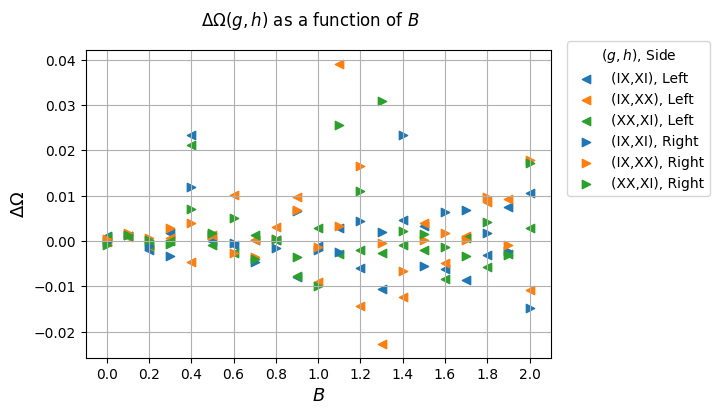

In [73]:
fig, ax = plt.subplots(figsize=(6, 4))

for i, (marker, side_label) in enumerate(zip(markers, side_labels)):
    for j, (col, label) in enumerate(zip(colors, symmetry_pair_labels)):
        plt.scatter(
            b_params,
            delta_gauge_invariant_proj_rep_angle[:, i, j],
            marker=marker,
            color=col,
            label = f'({label}), {side_label}'
        )

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)

ax.grid()

ax.set_ylabel(r'$\Delta \Omega$', fontsize=13)
ax.set_xlabel('$B$', fontsize=13)

ax.legend(bbox_to_anchor=(1.02, 1.05), title='$(g,h)$, Side')

fig.suptitle(r'$\Delta \Omega(g,h)$ as a function of $B$')

fig.savefig(r'plots/ed_delta_proj_rep_angle_from_mpo_bosonic.png', dpi=200)

In [74]:
np.max(np.abs(delta_gauge_invariant_proj_rep_angle))

0.03913240017626721

In [75]:
np.max(np.abs(delta_gauge_invariant_proj_rep_angle))/(np.pi/2)

0.02491245969241233

In [76]:
gauge_invariant_proj_rep_angle = np.imag(np.log(gauge_invariant_proj_rep_phase))
gauge_invariant_proj_rep_angle[gauge_invariant_proj_rep_angle<=-np.pi/2] += 2*np.pi

In [77]:
gauge_invariant_proj_rep_angle.shape

(21, 2, 3)

In [78]:
mean_gauge_invariant_proj_rep_angle = np.mean(gauge_invariant_proj_rep_angle, axis=(1,2))
max_gauge_invariant_proj_rep_angle = np.max(gauge_invariant_proj_rep_angle, axis=(1,2))
min_gauge_invariant_proj_rep_angle = np.min(gauge_invariant_proj_rep_angle, axis=(1,2))

min_max_gauge_invariant_proj_rep_angle = np.stack(
    [
        min_gauge_invariant_proj_rep_angle,
        max_gauge_invariant_proj_rep_angle
    ],
    axis=0
)

error_gauge_invariant_proj_rep_angle = (
    min_max_gauge_invariant_proj_rep_angle
    - mean_gauge_invariant_proj_rep_angle[np.newaxis, :]
)
error_gauge_invariant_proj_rep_angle = np.abs(error_gauge_invariant_proj_rep_angle)

In [79]:
np.max(error_gauge_invariant_proj_rep_angle)

0.03142499980137064

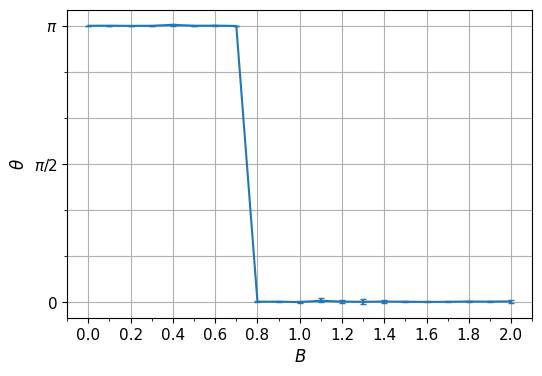

In [80]:
fig, ax = plt.subplots(figsize=(6,4))

plt.errorbar(
    b_params,
    mean_gauge_invariant_proj_rep_angle,
    yerr=error_gauge_invariant_proj_rep_angle,
    color='tab:blue',
    fmt='-',
    capsize=2
)

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)
ax.xaxis.set_minor_locator(
    matplotlib.ticker.MultipleLocator(0.1)
)

ax.set_yticks(
    np.linspace(0, np.pi, 3),
    labels=['$0$', '$\pi/2$', '$\pi$']
)

ax.set_yticks(
    [np.pi/6, np.pi/3, 2*np.pi/3, 5*np.pi/6],
    minor=True
)

ax.tick_params(
    axis='both',
    which='major',
    labelsize=11
)

ax.grid(
    axis='y',
    which='both'
)
ax.grid(
    axis='x',
    which='major'
)

ax.set_ylabel(r'$\theta$', fontsize=12)
ax.set_xlabel('$B$', fontsize=12)

fig.savefig(r'plots/proj_rep_angle_from_mpo_ed_bosonic.png', dpi=200)

In [81]:
scores = list()
for t in b_params:

    scores.append([best_boundary_operators[(t, i)][0] for i in [1,2,3]])

scores = np.array(scores)

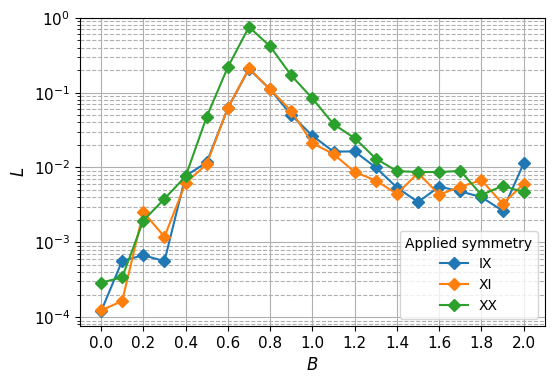

In [82]:
fig, ax = plt.subplots(figsize=(6,4))

for j, (col, label) in enumerate(zip(colors, symmetry_labels[1:])):
    plt.plot(
        b_params,
        scores[:, j],
        color=col,
        label = label,
        marker='D'
    )

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)

ax.set_yscale('log')
ax.set_ylim(bottom=None, top=1)
ax.tick_params(
    axis='both',
    which='major',
    labelsize=11
)

ax.grid()
ax.grid(
    which='minor',
    axis='y',
    linestyle='--',
    zorder=-1e10
)
ax.set_axisbelow(True)

ax.set_ylabel(r'$L$', fontsize=12)
ax.set_xlabel('$B$', fontsize=12)

ax.legend(loc='lower right', title='Applied symmetry')

#fig.suptitle(r'Final cost $L$ with symmetry $g$ as a function of $B$')

fig.savefig(r'plots/ed_cost_function_from_mpo_bosonic.png', dpi=200)

## Recalculate score components

In [83]:
def generate_problem_rdm(quimb_psi, symmetry_site_pairs, leftmost_symmetry_site,
                         num_symmetry_sites, num_boundary_sites):
    q_top = quimb_psi.copy(deep=True)
    for i, s in symmetry_site_pairs:
        q_top.gate(
            s,
            where=i,
            contract=False,
            inplace=True
        )

    
    indices_to_map = list(chain(
        range(leftmost_symmetry_site-num_boundary_sites, leftmost_symmetry_site),
        range(leftmost_symmetry_site+num_symmetry_sites, leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites)
    ))

    index_mapping = {f'k{i}': f'b{i}' for i in indices_to_map}

    q_bottom = (
        quimb_psi
        .copy()
        .reindex(index_mapping, inplace=True)
        .conj()
    )

    sites_to_contract = {
        'left': list(range(leftmost_symmetry_site-num_boundary_sites)),
        'middle': list(range(leftmost_symmetry_site, leftmost_symmetry_site+num_symmetry_sites)),
        'right': list(range(leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites, quimb_psi.L))
    }

    tags_to_contract = {
        k: [f'I{i}' for i in v]
        for k, v in sites_to_contract.items()
    }

    tn = (q_top & q_bottom)

    """
    tnc = (
        tn
        .contract(tags_to_contract['left'])
        .contract(tags_to_contract['middle'])
        .contract(tags_to_contract['right'])
    )
    """

    tnc = tn.contract()

    return tnc

In [84]:
def split_mpo_pair(mpo_pair):
    ml = qtn.TensorNetwork(
        list(map(mpo_pair.tensor_map.__getitem__, mpo_pair.tag_map['left_mpo']))
    )

    mr = qtn.TensorNetwork(
        list(map(mpo_pair.tensor_map.__getitem__, mpo_pair.tag_map['right_mpo']))
    )

    return (ml, mr)

In [85]:
def loss_overlap(ml, mr, rdm_tn, epsilon=0):
    c = (rdm_tn & ml & mr) ^ ...

    c_abs_squared = (
        c
        *jnp.conjugate(c)
    )
    #c_abs_squared = c_abs_squared.astype('float32')
    c_abs = (jnp.sqrt(jnp.real(c_abs_squared+epsilon)))

    return c_abs

In [86]:
def unitarity_tn(tn, total_physical_dim):
    ms = [tn.copy(), tn.copy(), tn.copy()]

    relabel_mpo(ms[0], 'k', 'l')
    relabel_mpo(ms[1], 'm', 'l')
    relabel_mpo(ms[2], 'm', 'b')

    ms[0] = ms[0].conj()
    ms[2] = ms[2].conj()

    n2tn = (tn & tn.conj())
    n2 = n2tn.contract(n2tn.tag_map)
    n4tn = (tn & ms[0] & ms[1] & ms[2])
    n4 = n4tn.contract(n4tn.tag_map)

    out = jnp.real(n4 - 2*n2 + total_physical_dim)

    return out

In [87]:
num_boundary_sites=4
left_most_symmetry_site=5
num_symmetry_sites=4
bond_dimension=5

total_physical_dim = 2**num_boundary_sites

In [88]:
unitarities_dict = dict()

for k, v in best_boundary_operators.items():
    pair = v[1]
    ml, mr = split_mpo_pair(pair)
    left_unitarity = unitarity_tn(ml, total_physical_dim)
    right_unitarity = unitarity_tn(mr, total_physical_dim)

    unitarities_dict[k] = (left_unitarity, right_unitarity)

In [89]:
np.mean(np.array(list(unitarities_dict.values())))

0.007750042

In [90]:
np.max(np.array(list(unitarities_dict.values())))

0.07119751

In [91]:
overlaps_dict = dict()

for k1, mps_psi in psi_dict.items():

    q1 = qtn.Dense1D(
        mps_psi.to_ndarray(),
        phys_dim=2
    )

    for k2, bs in enumerate(symmetry_actions[1:], start=1):
        symmetry_site_pairs = (
            [(i, bs[0]) for i in range(left_most_symmetry_site, left_most_symmetry_site+num_symmetry_sites, 2)]
            + [(i, bs[1]) for i in range(left_most_symmetry_site+1, left_most_symmetry_site+num_symmetry_sites+1, 2)]
        )

        problem_rdm = generate_problem_rdm(
            q1,
            symmetry_site_pairs,
            left_most_symmetry_site,
            num_symmetry_sites,
            num_boundary_sites
        )

        
        ml, mr = split_mpo_pair(best_boundary_operators[(k1, k2)][1])
        overlap = loss_overlap(ml, mr, problem_rdm)

        overlaps_dict[(k1, k2)] = overlap

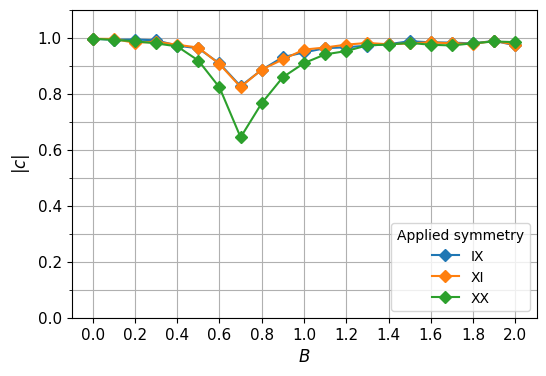

In [92]:
fig, ax = plt.subplots(figsize=(6,4))

for j, (col, label) in enumerate(zip(colors, symmetry_labels[1:]), start=1):
    plt.plot(
        b_params,
        [overlaps_dict[(b, j)] for b in b_params],
        color=col,
        label=label,
        marker='D'
    )

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)
ax.yaxis.set_minor_locator(
    matplotlib.ticker.MultipleLocator(0.1)
)

ax.set_ylim(0, 1.1)
ax.tick_params(
    axis='both',
    which='major',
    labelsize=11
)

ax.grid(
    which='both',
    axis='y'
)
ax.grid(
    which='major',
    axis='x'
)

ax.set_ylabel(r'$\vert c \vert$', fontsize=12)
ax.set_xlabel('$B$', fontsize=12)

ax.legend(loc='lower right', title='Applied symmetry')

fig.savefig(r'plots/overlap_mpo_ed_bosonic.png', dpi=200)

In [93]:
with open(r'../make_plots/data/bosonic_results/ed_b_params.pkl', 'wb') as f:
    pickle.dump(b_params, f)

In [96]:
with open(r'../make_plots/data/bosonic_results/quimb_ed_overlaps_dict.pkl', 'wb') as f:
    pickle.dump(overlaps_dict, f)

In [94]:
with open(r'../make_plots/data/bosonic_results/quimb_ed_mean_gauge_invariant_proj_rep_angle.pkl', 'wb') as f:
    pickle.dump(mean_gauge_invariant_proj_rep_angle, f)
with open(r'../make_plots/data/bosonic_results/quimb_ed_error_gauge_invariant_proj_rep_angle.pkl', 'wb') as f:
    pickle.dump(error_gauge_invariant_proj_rep_angle, f)

In [95]:
with open(r'../make_plots/data/bosonic_results/quimb_ed_optimisation_scores.pkl', 'wb') as f:
    pickle.dump(scores, f)